<a href="https://colab.research.google.com/github/morenakukurin/Repo_AIbio/blob/4.-vela/REGRESIJA_SAMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linearna regresija

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
np.random.seed(42)
blood_pressure = 2*np.random.rand(100,1)
inflamation_level = 4+3*blood_pressure+ np.random.randn(100, 1)
print(f'Blood pressure: {blood_pressure.shape}\nInflamation level: {inflamation_level.shape}')

Blood pressure: (100, 1)
Inflamation level: (100, 1)


In [5]:
#tu je flatten
data = pd.DataFrame({'Blood pressure (mmHg)':blood_pressure.flatten(),
                     'Inflamation level (Biomarker)': inflamation_level.flatten()})

In [6]:
data.head()

,Blood pressure (mmHg),Inflamation level (Biomarker)
0,0.749080,6.334288
1,1.901429,9.405278
2,1.463988,8.483724
3,1.197317,5.604382
4,0.312037,4.716440


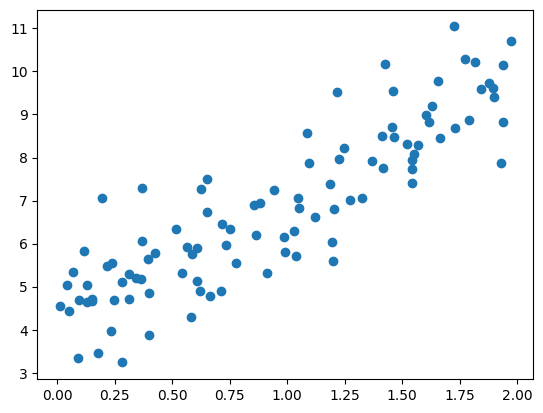

In [7]:
plt.scatter(data['Blood pressure (mmHg)'], data['Inflamation level (Biomarker)'])

/tmp/ipython-input-653038420.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


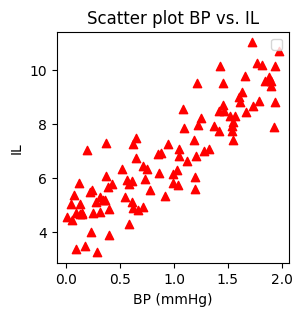

In [8]:
plt.figure(figsize=(3,3))
plt.scatter(x = data.iloc[:,0], y=data.iloc[:,1], color='red', marker="^")
plt.title('Scatter plot BP vs. IL')
plt.xlabel('BP (mmHg)')
plt.ylabel('IL')
plt.legend()


In [9]:
#splitanje
bp_train, bp_test, il_train, il_test = train_test_split(blood_pressure, inflamation_level, test_size=0.20)

In [10]:
model = LinearRegression()
model.fit(X=bp_train, y=il_train)

LinearRegression()

In [11]:
model.coef_

array([[2.77456502]])

In [12]:
model.intercept_

array([4.12656427])

In [13]:
#predikcija
il_pred = model.predict(bp_test)
il_pred

array([[8.40644372],
       [4.47925782],
       [8.91603742],
       [4.26761831],
       [8.18849384],
       [4.53744767],
       [5.22926343],
       [5.85224561],
       [6.7469463 ],
       [9.50691546],
       [4.8037703 ],
       [8.42787711],
       [8.57805964],
       [8.17524383],
       [4.66855953],
       [5.15234568],
       [4.99233199],
       [4.2407903 ],
       [9.60292822],
       [7.58532663]])

In [14]:
result = pd.DataFrame({'Test set IL': np.squeeze(il_test),'Pred set IL':np.squeeze(il_pred)})
result

,Test set IL,Pred set IL
0,7.947597,8.406444
1,5.037904,4.479258
2,11.044395,8.916037
3,4.429206,4.267618
4,8.483724,8.188494
5,4.676522,4.537448
6,3.871837,5.229263
7,4.891212,5.852246
8,7.246070,6.746946
9,8.826971,9.506915


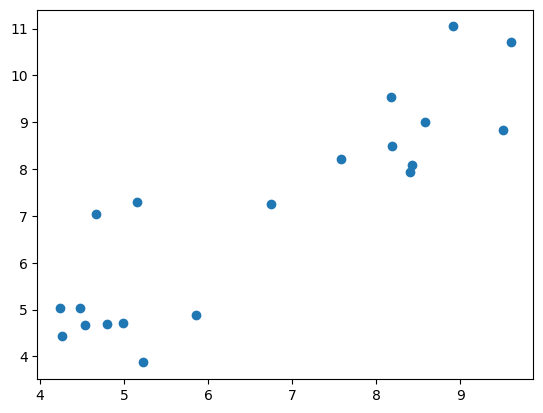

In [15]:
plt.scatter(x=result['Pred set IL'],y=result['Test set IL'])

#evaluacija linearne regresije

In [16]:
mse=mean_squared_error(il_test,il_pred)
r2 = r2_score(il_test,il_pred)
print(f'MSE = {round(mse, ndigits=3)}\nR^2 = {r2:.2f}')

MSE = 1.171
R^2 = 0.75


#Visestruka linearna regresija

In [50]:
dataset = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/regression_data.csv')
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
dataset.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


<Axes: xlabel='NO2', ylabel='Count'>

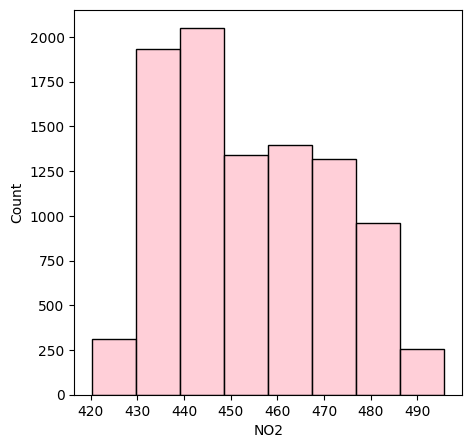

In [25]:
y.name = 'NO2' #za preimenovanje Seriesa
#X.columns za preimenovanja data frame-a

import seaborn as sns
plt.figure(figsize = (5,5))
sns.histplot(y, legend = True, binwidth = 10, color = 'pink')

In [26]:
dataset.corr()

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


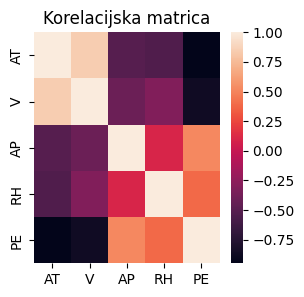

In [27]:
plt.figure(figsize = (3,3))
sns.heatmap(data=dataset.corr())
plt.title('Korelacijska matrica')
plt.show()

#Skaliranje
Standardizacija NE mijenja:
R²
predikcije modela

Mijenja:
vrijednosti koeficijenata
njihovu interpretaciju

In [29]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [31]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.20, random_state=0)

#Model

In [52]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [53]:
regressor.coef_

array([-1.97313099, -0.23649993,  0.06387891, -0.15807019])

In [54]:
pd.DataFrame({'coeficients':np.squeeze(regressor.coef_),'intercepts': np.squeeze(regressor.intercept_)}, index = X.columns)

,coeficients,intercepts
AT,-1.973131,452.841037
V,-0.236500,452.841037
AP,0.063879,452.841037
RH,-0.158070,452.841037


PREDIKCIJE MODELA

In [55]:
y_pred = regressor.predict(X_test)
y_pred

array([431.42761597, 458.56124622, 462.75264705, ..., 469.51835895,
       442.41759454, 461.88279939])

In [56]:
y_pred.shape, y_test.shape, X_test.shape

((1914,), (1914,), (1914, 4))

In [58]:
result = pd.DataFrame({'test':np.squeeze(y_test),'pred':np.squeeze(y_pred)})
result

,test,pred
4834,431.23,431.427616
1768,460.01,458.561246
2819,461.14,462.752647
7779,445.90,448.595962
7065,451.29,457.870777
...,...,...
6452,460.29,463.634916
794,452.42,457.035484
627,473.26,469.518359
3515,438.00,442.417595


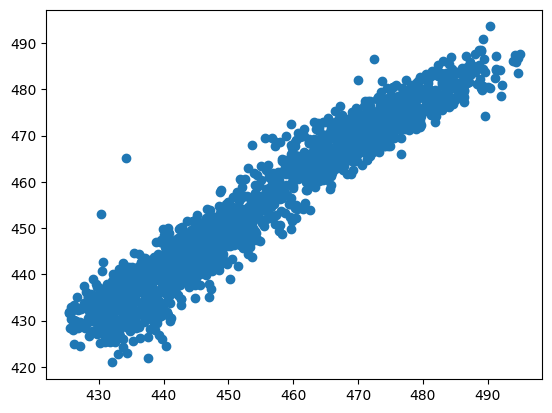

In [61]:
plt.scatter(x = result['test'], y = result['pred'])

In [68]:
from sklearn.metrics import r2_score, mean_squared_error

R2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 = {R2:.3f}\nRMSE = {rmse:.3f}")

R2 = 0.933
RMSE = 4.442
